In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('../data/raw/pr_data.csv')

print("DATASET OVERVIEW")
print(f"Total PRs collected : {len(df)}")
print(f"Total columns       : {len(df.columns)}")
print(f"Columns             : {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)

DATASET OVERVIEW
Total PRs collected : 900
Total columns       : 18
Columns             : ['pr_number', 'title', 'body', 'additions', 'deletions', 'changed_files', 'commits', 'comments', 'review_comments', 'num_reviewers', 'author', 'reviewers', 'files_changed', 'diff_patch', 'is_bug_fix', 'created_at', 'merged_at', 'repo']

Data types:
pr_number           int64
title              object
body               object
additions           int64
deletions           int64
changed_files       int64
commits             int64
comments            int64
review_comments     int64
num_reviewers       int64
author             object
reviewers          object
files_changed      object
diff_patch         object
is_bug_fix          int64
created_at         object
merged_at          object
repo               object
dtype: object


 MISSING VALUES
      Missing Count  Missing %
body             25       2.78


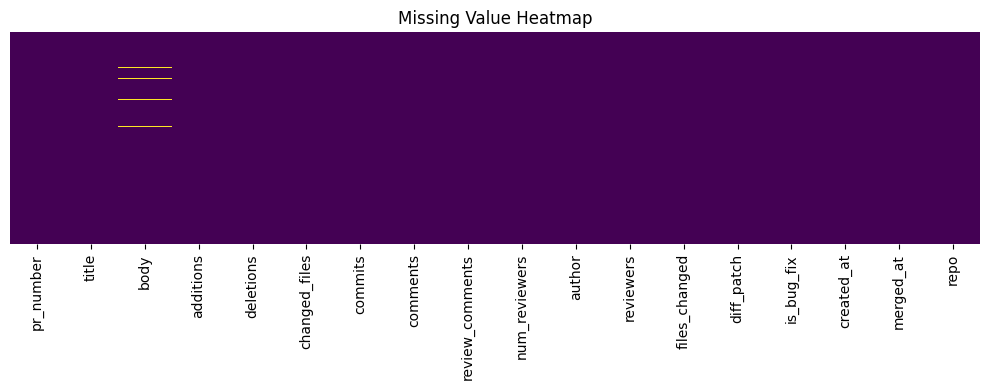

Saved → data/eda_missing_values.png


In [3]:
print(" MISSING VALUES")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct
}).query('`Missing Count` > 0')

if len(missing_report) == 0:
    print(" No missing values found")
else:
    print(missing_report)


plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.tight_layout()
plt.savefig('../data/eda_missing_values.png', dpi=150)
plt.show()
print("Saved → data/eda_missing_values.png")

BUG FIX DISTRIBUTION
Total bug-fixing PRs : 672
Total clean PRs      : 228
Bug fix rate         : 74.7%


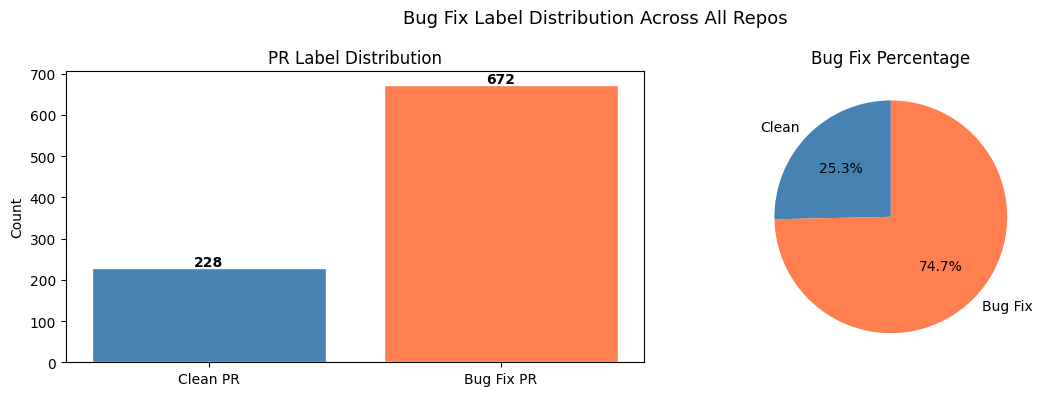


 Key finding: 74.7% of PRs in our dataset are bug-fixing


In [4]:
print("BUG FIX DISTRIBUTION")
bug_counts = df['is_bug_fix'].value_counts()
bug_rate = df['is_bug_fix'].mean()

print(f"Total bug-fixing PRs : {bug_counts[1]}")
print(f"Total clean PRs      : {bug_counts[0]}")
print(f"Bug fix rate         : {bug_rate:.1%}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].bar(['Clean PR', 'Bug Fix PR'], 
             [bug_counts[0], bug_counts[1]],
             color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('PR Label Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([bug_counts[0], bug_counts[1]]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')


axes[1].pie([bug_counts[0], bug_counts[1]], 
             labels=['Clean', 'Bug Fix'],
             colors=['steelblue', 'coral'],
             autopct='%1.1f%%', startangle=90)
axes[1].set_title('Bug Fix Percentage')

plt.suptitle('Bug Fix Label Distribution Across All Repos', fontsize=13)
plt.tight_layout()
plt.savefig('../data/eda_bug_distribution.png', dpi=150)
plt.show()
print(f"\n Key finding: {bug_rate:.1%} of PRs in our dataset are bug-fixing")

PER REPO ANALYSIS
                       total_prs  bug_fix_prs  bug_rate  avg_additions  \
repo                                                                     
facebook/react               300          190     0.633        656.680   
kubernetes/kubernetes        300          270     0.900        383.347   
microsoft/vscode             300          212     0.707        227.540   

                       avg_files  
repo                              
facebook/react            14.133  
kubernetes/kubernetes      8.683  
microsoft/vscode           5.690  


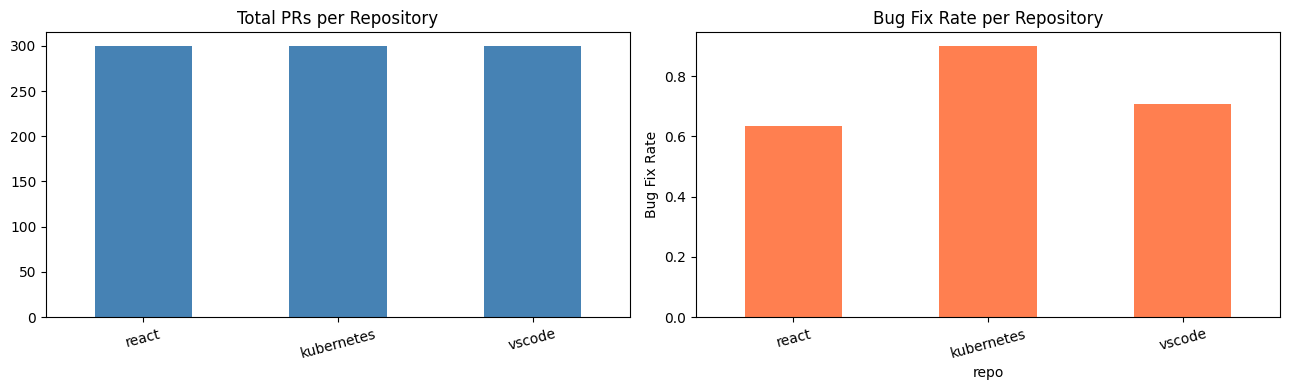


 Key finding: kubernetes has highest bug rate at 90.0%


In [5]:
print("PER REPO ANALYSIS")

repo_stats = df.groupby('repo').agg(
    total_prs    = ('is_bug_fix', 'count'),
    bug_fix_prs  = ('is_bug_fix', 'sum'),
    bug_rate     = ('is_bug_fix', 'mean'),
    avg_additions= ('additions', 'mean'),
    avg_files    = ('changed_files', 'mean')
).round(3)

print(repo_stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

repo_stats['total_prs'].plot(kind='bar', ax=axes[0], 
    color='steelblue', title='Total PRs per Repository')
axes[0].set_xlabel('')
axes[0].set_xticklabels(
    [r.split('/')[1] for r in repo_stats.index], rotation=15)

repo_stats['bug_rate'].plot(kind='bar', ax=axes[1],
    color='coral', title='Bug Fix Rate per Repository')
axes[1].set_ylabel('Bug Fix Rate')
axes[1].set_xticklabels(
    [r.split('/')[1] for r in repo_stats.index], rotation=15)

plt.tight_layout()
plt.savefig('../data/eda_per_repo.png', dpi=150)
plt.show()

print(f"\n Key finding: {repo_stats['bug_rate'].idxmax().split('/')[1]} has highest bug rate at {repo_stats['bug_rate'].max():.1%}")

PR SIZE ANALYSIS 
Average lines changed : 655
Median lines changed  : 79
Max lines changed     : 123595


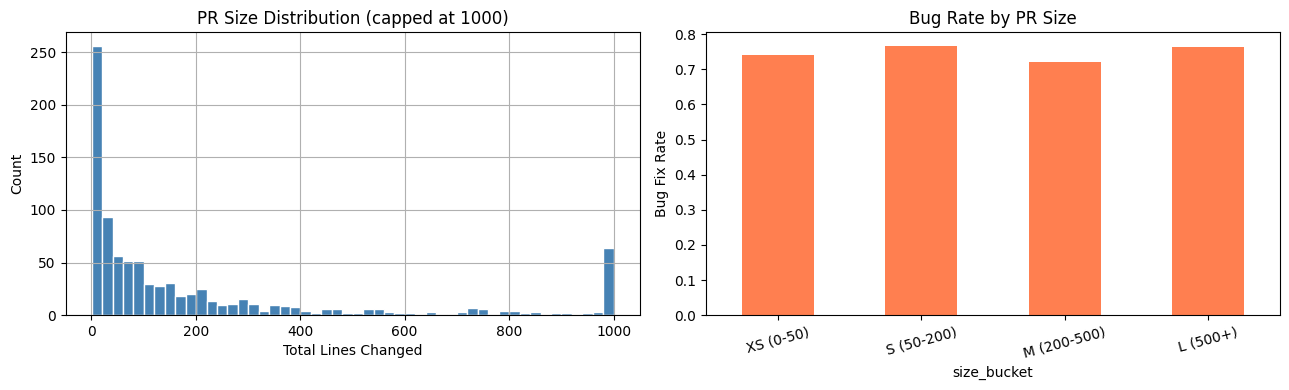


 Key finding: S (50-200) PRs have highest bug rate at 76.7%


In [6]:
print("PR SIZE ANALYSIS ")

df['total_changes'] = df['additions'] + df['deletions']

print(f"Average lines changed : {df['total_changes'].mean():.0f}")
print(f"Median lines changed  : {df['total_changes'].median():.0f}")
print(f"Max lines changed     : {df['total_changes'].max():.0f}")

# Size buckets
df['size_bucket'] = pd.cut(
    df['total_changes'],
    bins=[0, 50, 200, 500, 10000],
    labels=['XS (0-50)', 'S (50-200)', 'M (200-500)', 'L (500+)']
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution
df['total_changes'].clip(upper=1000).hist(
    bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('PR Size Distribution (capped at 1000)')
axes[0].set_xlabel('Total Lines Changed')
axes[0].set_ylabel('Count')

# Bug rate by size
bug_by_size = df.groupby('size_bucket')['is_bug_fix'].mean()
bug_by_size.plot(kind='bar', ax=axes[1], color='coral', 
                  title='Bug Rate by PR Size')
axes[1].set_ylabel('Bug Fix Rate')
axes[1].set_xticklabels(bug_by_size.index, rotation=15)

plt.tight_layout()
plt.savefig('../data/eda_pr_size.png', dpi=150)
plt.show()

print(f"\n Key finding: {bug_by_size.idxmax()} PRs have highest bug rate at {bug_by_size.max():.1%}")

FEATURE CORRELATION 


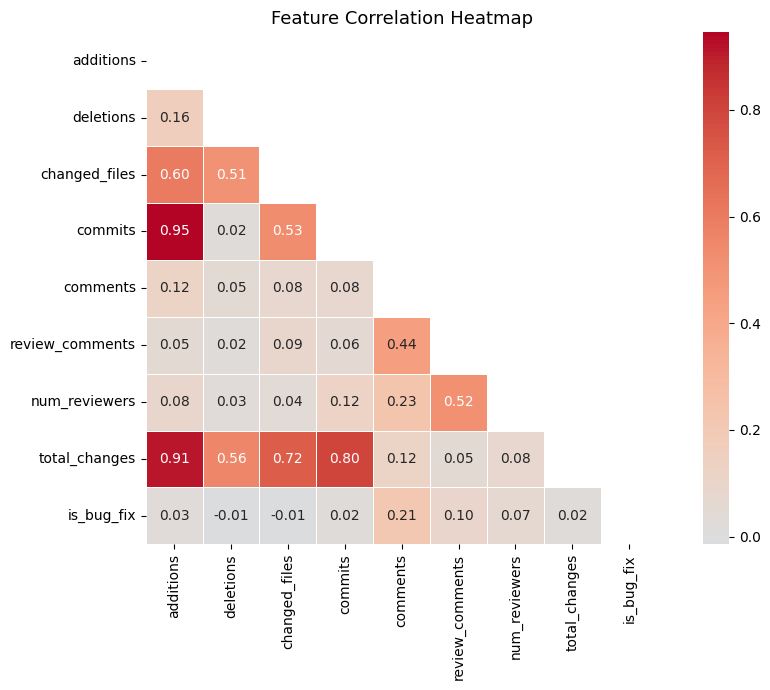


Correlation with bug fix label (sorted):
comments           0.213001
review_comments    0.096455
num_reviewers      0.065755
additions          0.025586
commits            0.021248
total_changes      0.018329
deletions         -0.007495
changed_files     -0.014438
Name: is_bug_fix, dtype: float64

Key finding: strongest predictor of bug PRs is above ↑


In [7]:
print("FEATURE CORRELATION ")

numeric_cols = [
    'additions', 'deletions', 'changed_files',
    'commits', 'comments', 'review_comments',
    'num_reviewers', 'total_changes', 'is_bug_fix'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True,
            linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('../data/eda_correlation.png', dpi=150)
plt.show()

# Print top correlations with bug label
print("\nCorrelation with bug fix label (sorted):")
print(corr['is_bug_fix'].drop('is_bug_fix').sort_values(ascending=False))
print(f"\nKey finding: strongest predictor of bug PRs is above ↑")

AUTHOR ANALYSIS
Unique authors : 227
Top 10 authors by PR count:
author
eps1lon                     86
josephsavona                34
meganrogge                  25
poteto                      23
serathius                   20
vs-code-engineering[bot]    19
hoxyq                       19
rickhanlonii                17
gnoff                       16
sandy081                    16
Name: count, dtype: int64

Top 10 authors by bug rate (min 5 PRs):
                 pr_count  bug_rate
author                             
HirazawaUi              6       1.0
adrianmoisey            5       1.0
hawkticehurst           5       1.0
aeschli                 5       1.0
brejman                 5       1.0
bart0sh                 5       1.0
dims                    7       1.0
dependabot[bot]         7       1.0
deepak1556              5       1.0
cpanato                 5       1.0


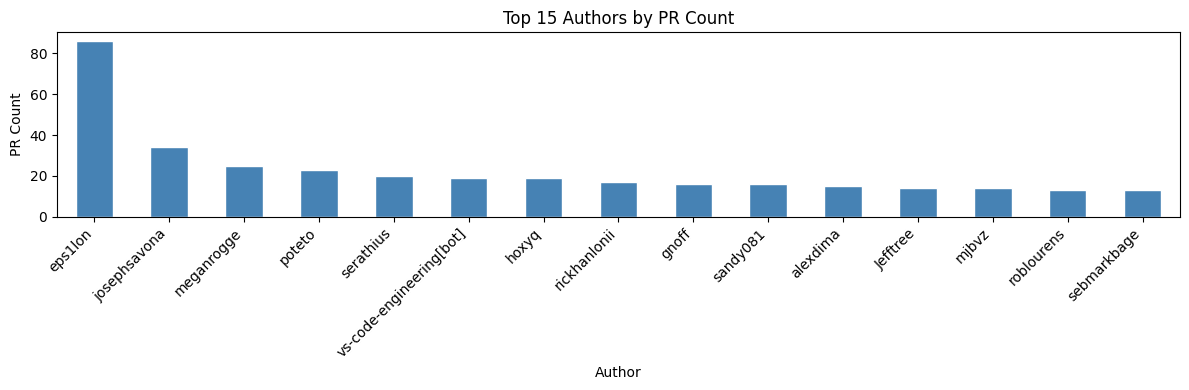

In [8]:
print("AUTHOR ANALYSIS")

print(f"Unique authors : {df['author'].nunique()}")
print(f"Top 10 authors by PR count:")
print(df['author'].value_counts().head(10))

# Authors with high bug rates (min 5 PRs)
author_stats = df.groupby('author').agg(
    pr_count = ('is_bug_fix', 'count'),
    bug_rate = ('is_bug_fix', 'mean')
).query('pr_count >= 5').sort_values('bug_rate', ascending=False)

print(f"\nTop 10 authors by bug rate (min 5 PRs):")
print(author_stats.head(10))

# Plot top 15 authors by PR volume
top_authors = df['author'].value_counts().head(15)

plt.figure(figsize=(12, 4))
top_authors.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 Authors by PR Count')
plt.xlabel('Author')
plt.ylabel('PR Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/eda_authors.png', dpi=150)
plt.show()

TIME ANALYSIS
Avg review time : 10.7 hours
Fastest merge   : 0.0 hours
Slowest merge   : 27851 hours


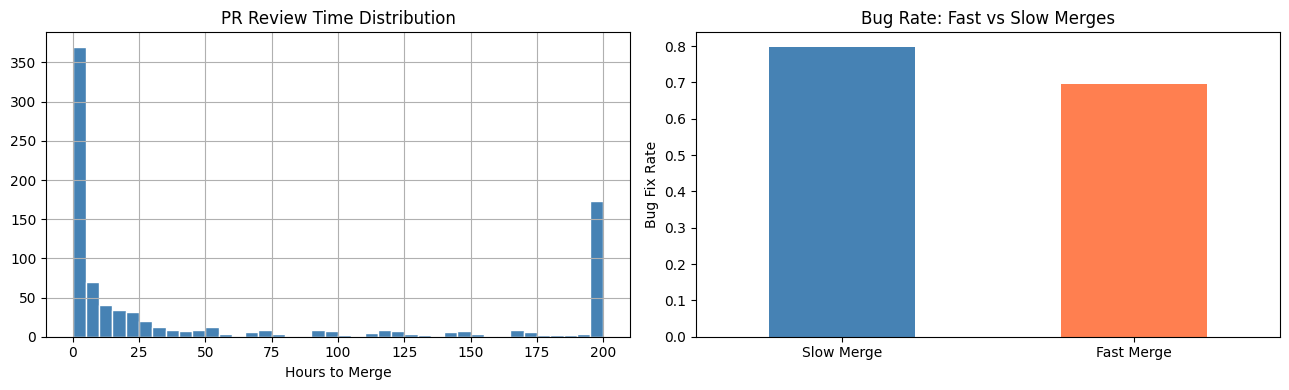


 Key finding: Fast merges have 69.6% bug rate vs 79.8% for slow merges


In [9]:
print("TIME ANALYSIS")

df['created_at'] = pd.to_datetime(df['created_at'])
df['merged_at']  = pd.to_datetime(df['merged_at'])

df['review_hours'] = (
    df['merged_at'] - df['created_at']
).dt.total_seconds() / 3600

df['merge_month'] = df['created_at'].dt.to_period('M')

print(f"Avg review time : {df['review_hours'].median():.1f} hours")
print(f"Fastest merge   : {df['review_hours'].min():.1f} hours")
print(f"Slowest merge   : {df['review_hours'].max():.0f} hours")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Review time distribution
df['review_hours'].clip(upper=200).hist(
    bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('PR Review Time Distribution')
axes[0].set_xlabel('Hours to Merge')

# Bug rate: fast vs slow merges
df['fast_merge'] = df['review_hours'] < df['review_hours'].median()
merge_bug = df.groupby('fast_merge')['is_bug_fix'].mean()
merge_bug.index = ['Slow Merge', 'Fast Merge']
merge_bug.plot(kind='bar', ax=axes[1], color=['steelblue','coral'])
axes[1].set_title('Bug Rate: Fast vs Slow Merges')
axes[1].set_ylabel('Bug Fix Rate')
axes[1].set_xticklabels(['Slow Merge', 'Fast Merge'], rotation=0)

plt.tight_layout()
plt.savefig('../data/eda_time_analysis.png', dpi=150)
plt.show()

print(f"\n Key finding: Fast merges have {merge_bug['Fast Merge']:.1%} bug rate vs {merge_bug['Slow Merge']:.1%} for slow merges")

In [10]:
# Save the enriched dataframe for task 3
df.to_csv('../data/raw/pr_data_eda.csv', index=False)

print("task 2 SUMMARY")
print(f" Total PRs analysed      : {len(df)}")
print(f" Bug fix rate            : {df['is_bug_fix'].mean():.1%}")
print(f" Unique authors          : {df['author'].nunique()}")
print(f" Unique repos            : {df['repo'].nunique()}")
print(f" Avg review time        : {df['review_hours'].median():.1f} hrs")
print(f" Charts saved           : 7 PNG files in data/")
print(f"\n task 2 complete — ready for preprocessing ")

task 2 SUMMARY
 Total PRs analysed      : 900
 Bug fix rate            : 74.7%
 Unique authors          : 227
 Unique repos            : 3
 Avg review time        : 10.7 hrs
 Charts saved           : 7 PNG files in data/

 task 2 complete — ready for preprocessing 
